<a href="https://colab.research.google.com/github/emanhassan2020/HandsOn/blob/main/MultiModal/similaritySearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q datasets faiss-gpu transformers sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.2/135.2 MB 7.5 MB/s eta 0:00:00


### Resolving `torchvision.io.VideoReader` ImportError

This error typically occurs due to version mismatches between `torch` and `torchvision`. The `datasets` library, when adding a FAISS index, might try to import `VideoReader` even if your data is not video-related. To resolve this, we'll reinstall `torch` and `torchvision` with compatible versions. It's often recommended to match `torchvision` to your `torch` version.

In [12]:
# Uninstall existing torch and torchvision to ensure a clean install
!pip uninstall -y torch torchvision torchaudio

# Install a specific, known-compatible version of torch and torchvision
# Using torch==2.5.0, torchvision==0.20.0, and torchaudio==2.5.0 as they are available for cu118
!pip install torch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 --index-url https://download.pytorch.org/whl/cu118

# Reinstall datasets and faiss-gpu, in case they were affected by the uninstallation
!pip install -q datasets faiss-gpu

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.3/838.3 MB ? eta 0:00:00
ERROR: Could not find a version that satisfies the requirement torchvision==0.20.0 (from versions: 0.1.6, 0.2.0, 0.21.0+cu118, 0.22.0+cu118, 0.22.1+cu118)
ERROR: No matching distribution found for torchvision==0.20.0


In [13]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 64.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 54.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 44.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 878.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 905.2/9

In [1]:
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer
import faiss
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

model = AutoModel.from_pretrained("openai/clip-vit-base-patch16").to(device)
processor = AutoImageProcessor.from_pretrained("openai/clip-vit-base-patch16")
tokenizer = AutoTokenizer.from_pretrained("openai/clip-vit-base-patch16")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [2]:
from datasets import load_dataset
ds = load_dataset("jmhessel/newyorker_caption_contest", "explanation")

In [3]:
ds["train"][0]["image"]
ds["train"][0]["image_description"]

'Two women are looking out a window. There is snow outside, and there is a snowman with human arms.'

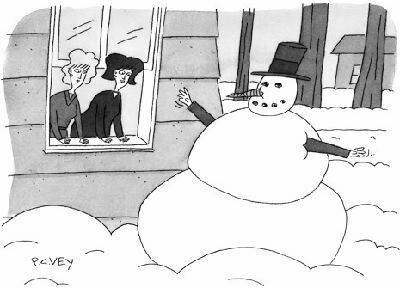

In [4]:
ds["train"][0]["image"]


In [5]:
dataset = ds["train"]
ds_with_embeddings = dataset.map(lambda example:
                                {'embeddings': model.get_text_features(
                                    **tokenizer([example["image_description"]],
                                                truncation=True, return_tensors="pt")
                                    .to("cuda"))[0].detach().cpu().numpy()})

In [6]:
ds_with_embeddings = ds_with_embeddings.map(lambda example:
                                          {'image_embeddings': model.get_image_features(
                                              **processor([example["image"]], return_tensors="pt")
                                              .to("cuda"))[0].detach().cpu().numpy()})


In [10]:
ds_with_embeddings.add_faiss_index(column='embeddings')

  0%|          | 0/3 [00:00<?, ?it/s]

ValueError: not enough values to unpack (expected 2, got 1)

In [11]:
ds_with_embeddings.add_faiss_index(column='image_embeddings')

  0%|          | 0/3 [00:00<?, ?it/s]

ValueError: too many values to unpack (expected 2)

In [9]:
print(ds_with_embeddings[0]['embeddings'].shape)
print(ds_with_embeddings[0]['image_embeddings'].shape)

AttributeError: 'list' object has no attribute 'shape'

In [12]:
prmt = "a snowy day"
prmt_embedding = model.get_text_features(**tokenizer([prmt], return_tensors="pt", truncation=True).to("cuda"))[0].detach().cpu().numpy()
scores, retrieved_examples = ds_with_embeddings.get_nearest_examples('embeddings', prmt_embedding, k=1)


MissingIndex: Index with index_name 'embeddings' not initialized yet. Please make sure that you call `add_faiss_index` or `add_elasticsearch_index` first.

In [ ]:
def downscale_images(image):
  width = 200
  ratio = (width / float(image.size[0]))
  height = int((float(image.size[1]) * float(ratio)))
  img = image.resize((width, height), Image.Resampling.LANCZOS)
  return img

images = [downscale_images(image) for image in retrieved_examples["image"]]
# see the closest text and image
print(retrieved_examples["image_description"])
display(images[0])

In [ ]:
import requests
# image of a beaver
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/beaver.png"
image = Image.open(requests.get(url, stream=True).raw)
display(downscale_images(image))

In [ ]:
img_embedding = model.get_image_features(**processor([image], return_tensors="pt", truncation=True).to("cuda"))[0].detach().cpu().numpy()
scores, retrieved_examples = ds_with_embeddings.get_nearest_examples('image_embeddings', img_embedding, k=1)


In [ ]:
images = [downscale_images(image) for image in retrieved_examples["image"]]
# see the closest text and image
print(retrieved_examples["image_description"])
display(images[0])

In [ ]:
ds_with_embeddings.save_faiss_index('embeddings', 'embeddings/embeddings.faiss')
ds_with_embeddings.save_faiss_index('image_embeddings', 'embeddings/image_embeddings.faiss')


In [ ]:
from huggingface_hub import HfApi, notebook_login, snapshot_download
notebook_login()

In [ ]:
from huggingface_hub import HfApi
api = HfApi()
api.create_repo("merve/faiss_embeddings", repo_type="dataset")
api.upload_folder(
    folder_path="./embeddings",
    repo_id="merve/faiss_embeddings",
    repo_type="dataset",
)

In [ ]:
snapshot_download(repo_id="merve/faiss_embeddings", repo_type="dataset",
                  local_dir="downloaded_embeddings")

In [ ]:
ds = ds["train"]
ds.load_faiss_index('embeddings', './downloaded_embeddings/embeddings.faiss')
# infer again
prmt = "people under the rain"

In [ ]:
prmt_embedding = model.get_text_features(
                        **tokenizer([prmt], return_tensors="pt", truncation=True)
                        .to("cuda"))[0].detach().cpu().numpy()

scores, retrieved_examples = ds.get_nearest_examples('embeddings', prmt_embedding, k=1)

In [ ]:
display(retrieved_examples["image"][0])